**ReAct Agent**

-Refers to Reason and Action AGent

-Learn to create tools in Langgraph

-Learn React Architecture

-Work with different types of messages e.g ToolMessage, HumanMessage,AIMessage

**Goat:** Create a robust ReAct Agent

![Screenshot 2025-08-19 143348.png](<attachment:Screenshot 2025-08-19 143348.png>)
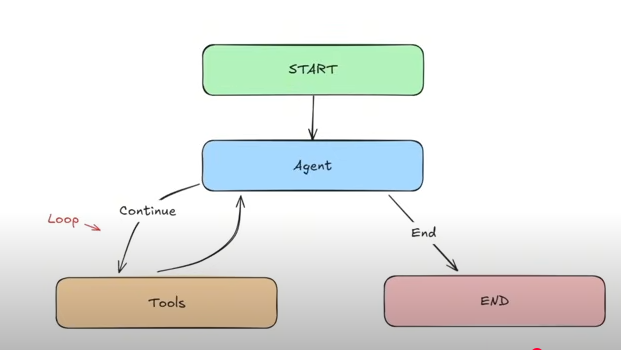

**Annotated**- Provide additional context without affecting the type itself

**Sequence**- It handles the state updates for sequences such as adding new messages to a chat history

**ToolMessage**- Passes data back to the LLM after it calls a tool such as the content and the tool_Call_id

**SystemMessage**-Message for providing instructions to the LLM

**BaseMessage**- Parent class. Foundation class for all message types in Langgraph

**Tool and ToolNode**- Are central to enabling Agents to interact with external functionalities. They allow an Agent to interact with the outside world.

**add_messages**-This is a reducer function. Reducer function is a rule that controols how updates from nodes are combined with the exisiting state. Tells us how to merge new data to the current state. 

*N/B:* WITHOUT A REDUCER, updates would have replaced the existing value entirely!



In [2]:
#!/usr/bin/python3
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
import os
from langchain_core.messages import BaseMessage
from langchain_core.messages import ToolMessage
from langchain_core.messages import SystemMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode


In [3]:
load_dotenv()

#set up our LLM in our casee llama on groq 
llm = ChatGroq(
    temperature=0.3,  # Lower temperature for more factual responses
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.3-70b-versatile"
)

In [4]:

#create the state schema
class AgentState(TypedDict):
    #REDUCER function: reserve the state by appending and not overriding
    messages: Annotated[Sequence[BaseMessage],add_messages]



In [16]:
#we use a tool decorator to create a tool
@tool
def add(a:int, b:int)->int:
    """This is an addition function that adds 2 numbers together"""
    return a+b

@tool
def subtract(a: int, b:int)->int:
    """Use this to perform subtraction"""
    return a-b

@tool
def multiply(a: int, b: int):
    """Multiplication function"""
    return a*b

#now add the tool for our model
tools=[add, subtract,multiply]
model=llm.bind_tools(tools)

In [17]:
#add node
def model_call(state: AgentState)->AgentState:
    system_prompt=SystemMessage(content=
        "You are my AI Assistant, please Answer my query to the best of your ability."                            
    )
    #pass our system prompt
    response=model.invoke([system_prompt] + state["messages"])
    #now update the graph state
    return {"messages":[response]}

#this is a conditional edge node
def should_continue(state:AgentState):
    messages=state['messages']
    last_message=messages[-1]
    if not last_message.tool_calls:
        return "end"
    else: 
        return "continue"
    

In [18]:
#build the graph
graph=StateGraph(AgentState)

#add node
graph.add_node('our_agent', model_call)

#now add the tool node to our graph
tool_node=ToolNode(tools=tools)
graph.add_node("tools", tool_node)

#add edges to connect the node
graph.set_entry_point("our_agent")

#this connects our agent to the tools. Conditionally
graph.add_conditional_edges(
    "our_agent", #source node
    should_continue, #action
    {
        "continue":"tools",
        "end":END 
    }
)

#add the edge to connect the tool node to our agent
graph.add_edge("tools", "our_agent")

#comile graph
app=graph.compile()

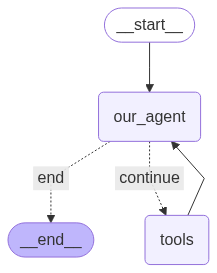

In [19]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [20]:
def print_stream(stream):
    for s in stream:
        message=s["messages"][-1]

        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [21]:

inputs={"messages":[("user", "Add 3+4")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 3+4
================================== Ai Message ==================================
Tool Calls:
  add (thpgd370b)
 Call ID: thpgd370b
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The result of the addition is 7.


In [15]:

inputs={"messages":[("user", "Add 3+4 and also add 100+892 and also add 12+12")]}
print_stream(app.stream(inputs, stream_mode="values"))



================================ Human Message =================================

Add 3+4 and also add 100+892 and also add 12+12
================================== Ai Message ==================================
Tool Calls:
  add (1pg859p6e)
 Call ID: 1pg859p6e
  Args:
    a: 3
    b: 4
  add (e2jtp7rqb)
 Call ID: e2jtp7rqb
  Args:
    a: 100
    b: 892
  add (jyqq0mx2r)
 Call ID: jyqq0mx2r
  Args:
    a: 12
    b: 12
================================= Tool Message =================================
Name: add

24
================================== Ai Message ==================================

The results of the additions are:
- 3 + 4 = 7
- 100 + 892 = 992
- 12 + 12 = 24


In [22]:
inputs={"messages":[("user", "Add 40 plus 12, subtract 5 and multiply the results by 6")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 plus 12, subtract 5 and multiply the results by 6
================================== Ai Message ==================================
Tool Calls:
  add (z7qrw755h)
 Call ID: z7qrw755h
  Args:
    a: 40
    b: 12
  subtract (7ztraz3c3)
 Call ID: 7ztraz3c3
  Args:
    a: 52
    b: 5
  multiply (ez9ewd4f0)
 Call ID: ez9ewd4f0
  Args:
    a: 47
    b: 6
================================= Tool Message =================================
Name: multiply

282
================================== Ai Message ==================================

The result of the operations is 282.


In [23]:
inputs={"messages":[("user", "Add 40 plus 12, subtract 5 and multiply the results by 6. Also tell me a joke please")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 plus 12, subtract 5 and multiply the results by 6. Also tell me a joke please
================================== Ai Message ==================================
Tool Calls:
  add (gxjnksxzh)
 Call ID: gxjnksxzh
  Args:
    a: 40
    b: 12
  subtract (x68mx0mxp)
 Call ID: x68mx0mxp
  Args:
    a: 52
    b: 5
  multiply (99stj7q1h)
 Call ID: 99stj7q1h
  Args:
    a: 47
    b: 6
================================= Tool Message =================================
Name: multiply

282
================================== Ai Message ==================================

Why couldn't the bicycle stand up by itself? Because it was two-tired.


In [24]:
inputs={"messages":[("user", "Hello, I am Allan. whats your system message?")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Hello, I am Allan. whats your system message?
================================== Ai Message ==================================

Hello Allan, I'm happy to assist you. My system message is that I'm ready to help with any questions or tasks you may have, and I have access to various functions such as addition, subtraction, and multiplication. How can I assist you today?


In [25]:
inputs={"messages":[("user", "do you have a name?")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

do you have a name?
================================== Ai Message ==================================

I'm an AI designed to assist and communicate with users in a helpful and informative way. I don't have a personal name, but I'm here to help answer your questions and provide information on a wide range of topics.
